# 02_Report - Báo cáo kết quả huấn luyện mô hình

Notebook này dùng để tổng hợp kết quả sau khi huấn luyện mô hình phân loại bệnh lá cây bằng EfficientNetB0 pretrained ImageNet.

Nội dung chính:

 - Thông tin bài toán
 - Kiểm tra dữ liệu train/val/test
 - Đọc log huấn luyện
 - Số lượng tham số trong mô hình
 - Hiển thị bảng accuracy/loss theo epoch
 - Hiển thị classification report
 - Hiển thị confusion matrix
 - Hiển thị các chỉ số tổng quát
 - So sánh dropout 0.2 và 0.8
 - Nhận xét và kết luận


In [9]:
import sys
from pathlib import Path

BASE_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

if str(BASE_DIR) not in sys.path:
    sys.path.append(str(BASE_DIR))

print(BASE_DIR)

d:\DL\PlantDisease_Local


In [10]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image

BASE_DIR = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()

DATA_DIR = BASE_DIR / 'data'
SPLIT_DIR = DATA_DIR / 'split'
TRAIN_DIR = SPLIT_DIR / 'train'
VAL_DIR = SPLIT_DIR / 'val'
TEST_DIR = SPLIT_DIR / 'test'

OUTPUT_DIR = BASE_DIR / 'outputs'
FIGURE_DIR = OUTPUT_DIR / 'figures'
RESULT_DIR = OUTPUT_DIR / 'results'

TRAIN_LOG_PATH = RESULT_DIR / 'training_log.csv'
REPORT_PATH = RESULT_DIR / 'classification_report.csv'
DROPOUT_COMPARE_PATH = RESULT_DIR / 'dropout_comparison.csv'

print('BASE_DIR:', BASE_DIR)
print('TRAIN_LOG_PATH:', TRAIN_LOG_PATH)
print('REPORT_PATH:', REPORT_PATH)
print('DROPOUT_COMPARE_PATH:', DROPOUT_COMPARE_PATH)

BASE_DIR: d:\DL\PlantDisease_Local
TRAIN_LOG_PATH: d:\DL\PlantDisease_Local\outputs\results\training_log.csv
REPORT_PATH: d:\DL\PlantDisease_Local\outputs\results\classification_report.csv
DROPOUT_COMPARE_PATH: d:\DL\PlantDisease_Local\outputs\results\dropout_comparison.csv


## 1. Thông tin bài toán

Bài toán là phân loại bệnh trên lá cây từ ảnh đầu vào.

Mô hình sử dụng:

- EfficientNetB0
- Pretrained trên ImageNet
- Thay classifier cuối theo số lớp bệnh lá cây
- Huấn luyện theo 2 giai đoạn:
  - Giai đoạn 1: Freeze backbone, chỉ train classifier
  - Giai đoạn 2: Fine-tune một phần backbone với learning rate nhỏ

Dữ liệu được chia thành:

- Train: 80%
- Validation: 10%
- Test: 10%


## 2. Kiểm tra số lượng ảnh trong train/val/test

In [11]:
image_extensions = ['.jpg', '.jpeg', '.png']

def count_images(folder):
    total = 0
    class_counts = []
    for class_dir in folder.iterdir():
        if class_dir.is_dir():
            n = sum(1 for p in class_dir.glob('*') if p.suffix.lower() in image_extensions)
            class_counts.append({'class_name': class_dir.name, 'num_images': n})
            total += n
    return total, pd.DataFrame(class_counts)

train_total, df_train = count_images(TRAIN_DIR)
val_total, df_val = count_images(VAL_DIR)
test_total, df_test = count_images(TEST_DIR)

total = train_total + val_total + test_total

df_split_summary = pd.DataFrame({
    'Split': ['Train', 'Validation', 'Test'],
    'Number of Images': [train_total, val_total, test_total],
    'Ratio': [train_total / total, val_total / total, test_total / total]
})

df_split_summary

,Split,Number of Images,Ratio
0,Train,43444,0.800000
1,Validation,5430,0.099991
2,Test,5431,0.100009


## 3. Kiểm tra số lớp

In [12]:
num_classes = len(df_train)
print('Số lớp:', num_classes)
df_train.head()

Số lớp: 38


,class_name,num_images
0,Apple___Apple_scab,504
1,Apple___Black_rot,497
2,Apple___Cedar_apple_rust,220
3,Apple___healthy,1316
4,Blueberry___healthy,1202


## 4. Kiểm tra stratify sau khi chia dữ liệu


In [13]:
df_stratify = df_train.rename(columns={'num_images': 'train_count'})
df_stratify = df_stratify.merge(df_val.rename(columns={'num_images': 'val_count'}), on='class_name', how='left')
df_stratify = df_stratify.merge(df_test.rename(columns={'num_images': 'test_count'}), on='class_name', how='left')
df_stratify = df_stratify.fillna(0)

df_stratify['total'] = df_stratify['train_count'] + df_stratify['val_count'] + df_stratify['test_count']
df_stratify['train_ratio'] = df_stratify['train_count'] / df_stratify['total']
df_stratify['val_ratio'] = df_stratify['val_count'] / df_stratify['total']
df_stratify['test_ratio'] = df_stratify['test_count'] / df_stratify['total']

df_stratify.head(10)

,class_name,train_count,val_count,test_count,total,train_ratio,val_ratio,test_ratio
0,Apple___Apple_scab,504,63,63,630,0.800000,0.100000,0.100000
1,Apple___Black_rot,497,62,62,621,0.800322,0.099839,0.099839
2,Apple___Cedar_apple_rust,220,28,27,275,0.800000,0.101818,0.098182
3,Apple___healthy,1316,164,165,1645,0.800000,0.099696,0.100304
4,Blueberry___healthy,1202,150,150,1502,0.800266,0.099867,0.099867
5,Cherry_(including_sour)___healthy,683,86,85,854,0.799766,0.100703,0.099532
6,Cherry_(including_sour)___Powdery_mildew,842,105,105,1052,0.800380,0.099810,0.099810
7,Corn_(maize)___Cercospora_leaf_spot Gray_leaf_...,410,52,51,513,0.799220,0.101365,0.099415
8,Corn_(maize)___Common_rust_,953,119,120,1192,0.799497,0.099832,0.100671
9,Corn_(maize)___healthy,930,116,116,1162,0.800344,0.099828,0.099828


In [14]:
df_stratify[['train_ratio', 'val_ratio', 'test_ratio']].describe()

,train_ratio,val_ratio,test_ratio
count,38.000000,38.000000,38.000000
mean,0.800044,0.100115,0.099841
std,0.000557,0.000646,0.000515
min,0.798928,0.098684,0.098182
25%,0.799866,0.099795,0.099745
50%,0.800000,0.100000,0.100000
75%,0.800188,0.100120,0.100120
max,0.802632,0.101877,0.100671


## 5. Đọc training log

Training log chỉ gồm train và validation theo epoch.


In [15]:
if TRAIN_LOG_PATH.exists():
    df_log = pd.read_csv(TRAIN_LOG_PATH)
    display(df_log)
else:
    print('Chưa tìm thấy training_log.csv. Hãy train model trước.')

,phase,epoch,train_acc,val_acc,train_loss,val_loss,avg_time_per_epoch
0,dropout_0.2_freeze,1,0.865022,0.936464,0.592835,0.224277,605.865124
1,dropout_0.2_freeze,2,0.926871,0.954144,0.255955,0.156808,298.463470
2,dropout_0.2_freeze,3,0.936378,0.960589,0.212044,0.130236,298.337481
3,dropout_0.2_freeze,4,0.938703,0.963904,0.192836,0.119768,299.839503
4,dropout_0.2_freeze,5,0.943168,0.963352,0.180623,0.111794,297.986647
5,dropout_0.2_finetune,1,0.950971,0.970718,0.151524,0.091822,298.242129
6,dropout_0.2_finetune,2,0.957278,0.972007,0.132752,0.087415,297.374011
7,dropout_0.2_finetune,3,0.960110,0.975138,0.122784,0.077662,298.287948
8,dropout_0.2_finetune,4,0.963931,0.976427,0.113706,0.068802,297.205040
9,dropout_0.2_finetune,5,0.967567,0.977716,0.101092,0.071097,298.541263


## 6. Số lượng tham số của mô hình

Phần này thống kê số lượng tham số của EfficientNetB0 sau khi thay classifier cho bài toán phân loại bệnh lá cây.

Các chỉ số bao gồm:

- Total Parameters: Tổng số tham số của mô hình.
- Trainable Parameters: Các tham số được cập nhật trong quá trình huấn luyện.
- Frozen Parameters: Các tham số bị đóng băng.

Việc đóng băng backbone được sử dụng trong giai đoạn transfer learning nhằm bảo toàn các đặc trưng đã học từ ImageNet.

In [16]:
import pandas as pd
from src.model import build_model, freeze_backbone
from src.utils import count_parameters

NUM_CLASSES = len(df_train)

results = []

for dropout in [0.2, 0.8]:

    # Mô hình ban đầu
    model = build_model(
        num_classes=NUM_CLASSES,
        dropout=dropout,
        pretrained=True
    )

    total, trainable, frozen = count_parameters(model)

    results.append({
        "Dropout": dropout,
        "Model State": "Pretrained",
        "Total Parameters": total,
        "Trainable Parameters": trainable,
        "Frozen Parameters": frozen
    })

    # Sau khi freeze backbone
    model = freeze_backbone(model)

    total, trainable, frozen = count_parameters(model)

    results.append({
        "Dropout": dropout,
        "Model State": "Freeze Backbone",
        "Total Parameters": total,
        "Trainable Parameters": trainable,
        "Frozen Parameters": frozen
    })

df_params = pd.DataFrame(results)

display(df_params)

,Dropout,Model State,Total Parameters,Trainable Parameters,Frozen Parameters
0,0.2,Pretrained,4056226,4056226,0
1,0.2,Freeze Backbone,4056226,48678,4007548
2,0.8,Pretrained,4056226,4056226,0
3,0.8,Freeze Backbone,4056226,48678,4007548


In [17]:
df_params_display = df_params.copy()

for col in [
    "Total Parameters",
    "Trainable Parameters",
    "Frozen Parameters"
]:
    df_params_display[col] = (
        df_params_display[col]
        .apply(lambda x: f"{x:,}")
    )

display(df_params_display)

,Dropout,Model State,Total Parameters,Trainable Parameters,Frozen Parameters
0,0.2,Pretrained,"4,056,226","4,056,226",0
1,0.2,Freeze Backbone,"4,056,226","48,678","4,007,548"
2,0.8,Pretrained,"4,056,226","4,056,226",0
3,0.8,Freeze Backbone,"4,056,226","48,678","4,007,548"


## 7. Bảng kết quả theo epoch

Bảng này gồm:

- Epoch
- Training Accuracy
- Validation Accuracy
- Training Loss
- Validation Loss
- Average Time per Epoch


In [18]:
if TRAIN_LOG_PATH.exists():
    df_epoch = df_log.copy()
    rename_cols = {
        'phase': 'Phase',
        'epoch': 'Epoch',
        'train_acc': 'Training Accuracy',
        'val_acc': 'Validation Accuracy',
        'train_loss': 'Training Loss',
        'val_loss': 'Validation Loss',
        'avg_time_per_epoch': 'Average Time per Epoch'
    }
    df_epoch = df_epoch.rename(columns=rename_cols)
    display(df_epoch)
else:
    print('Chưa có log huấn luyện.')

,Phase,Epoch,Training Accuracy,Validation Accuracy,Training Loss,Validation Loss,Average Time per Epoch
0,dropout_0.2_freeze,1,0.865022,0.936464,0.592835,0.224277,605.865124
1,dropout_0.2_freeze,2,0.926871,0.954144,0.255955,0.156808,298.463470
2,dropout_0.2_freeze,3,0.936378,0.960589,0.212044,0.130236,298.337481
3,dropout_0.2_freeze,4,0.938703,0.963904,0.192836,0.119768,299.839503
4,dropout_0.2_freeze,5,0.943168,0.963352,0.180623,0.111794,297.986647
5,dropout_0.2_finetune,1,0.950971,0.970718,0.151524,0.091822,298.242129
6,dropout_0.2_finetune,2,0.957278,0.972007,0.132752,0.087415,297.374011
7,dropout_0.2_finetune,3,0.960110,0.975138,0.122784,0.077662,298.287948
8,dropout_0.2_finetune,4,0.963931,0.976427,0.113706,0.068802,297.205040
9,dropout_0.2_finetune,5,0.967567,0.977716,0.101092,0.071097,298.541263


## 8. Biểu đồ Accuracy Curve

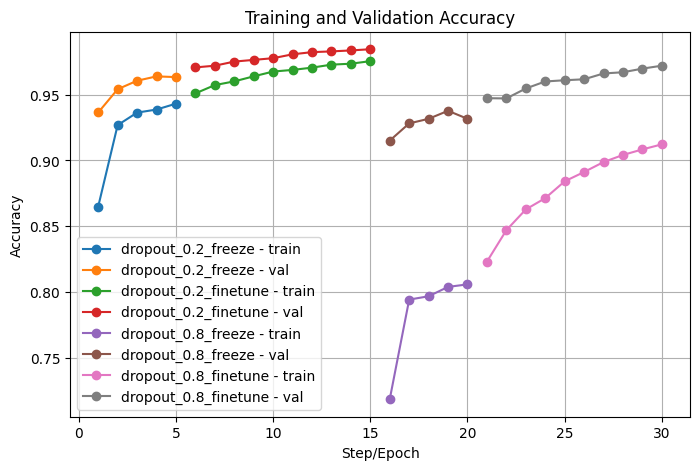

In [19]:
if TRAIN_LOG_PATH.exists():
    plt.figure(figsize=(8, 5))
    for phase in df_log['phase'].unique():
        df_phase = df_log[df_log['phase'] == phase]
        plt.plot(df_phase.index + 1, df_phase['train_acc'], marker='o', label=f'{phase} - train')
        plt.plot(df_phase.index + 1, df_phase['val_acc'], marker='o', label=f'{phase} - val')
    plt.xlabel('Step/Epoch')
    plt.ylabel('Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print('Chưa có dữ liệu để vẽ accuracy curve.')

## 9. Biểu đồ Loss Curve

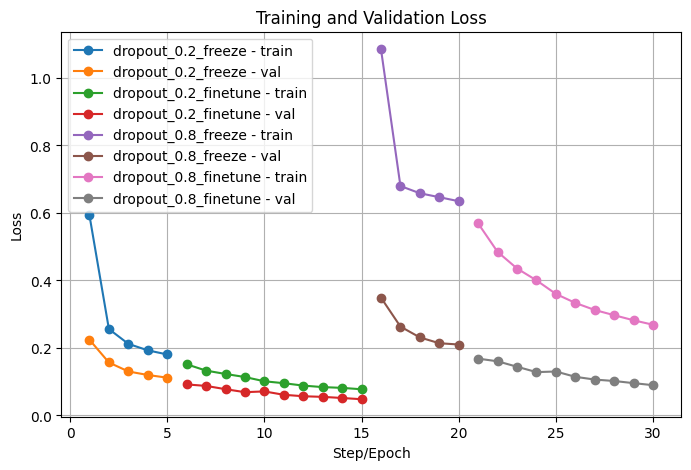

In [20]:
if TRAIN_LOG_PATH.exists():
    plt.figure(figsize=(8, 5))
    for phase in df_log['phase'].unique():
        df_phase = df_log[df_log['phase'] == phase]
        plt.plot(df_phase.index + 1, df_phase['train_loss'], marker='o', label=f'{phase} - train')
        plt.plot(df_phase.index + 1, df_phase['val_loss'], marker='o', label=f'{phase} - val')
    plt.xlabel('Step/Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print('Chưa có dữ liệu để vẽ loss curve.')

## 10. Đọc classification report trên test set



In [21]:
if REPORT_PATH.exists():
    df_report = pd.read_csv(REPORT_PATH, index_col=0)
    display(df_report)
else:
    print('Chưa tìm thấy classification_report.csv. Hãy chạy evaluate trước.')

,precision,recall,f1-score,support
Apple___Apple_scab,0.953125,0.968254,0.960630,63.000000
Apple___Black_rot,1.000000,1.000000,1.000000,62.000000
Apple___Cedar_apple_rust,1.000000,0.962963,0.981132,27.000000
Apple___healthy,0.987730,0.975758,0.981707,165.000000
Blueberry___healthy,1.000000,1.000000,1.000000,150.000000
Cherry_(including_sour)___Powdery_mildew,0.990566,1.000000,0.995261,105.000000
Cherry_(including_sour)___healthy,0.976744,0.988235,0.982456,85.000000
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot,0.945946,0.686275,0.795455,51.000000
Corn_(maize)___Common_rust_,0.966942,0.975000,0.970954,120.000000
Corn_(maize)___Northern_Leaf_Blight,0.834783,0.979592,0.901408,98.000000


## 11. Các chỉ số tổng quát trên test set

In [22]:
if REPORT_PATH.exists():
    summary_rows = ['accuracy', 'macro avg', 'weighted avg']
    existing_rows = [r for r in summary_rows if r in df_report.index]
    display(df_report.loc[existing_rows])
else:
    print('Chưa có classification report.')

,precision,recall,f1-score,support
accuracy,0.966305,0.966305,0.966305,0.966305
macro avg,0.962355,0.954644,0.957378,5431.000000
weighted avg,0.966509,0.966305,0.965863,5431.000000


## 12. Hiển thị Confusion Matrix

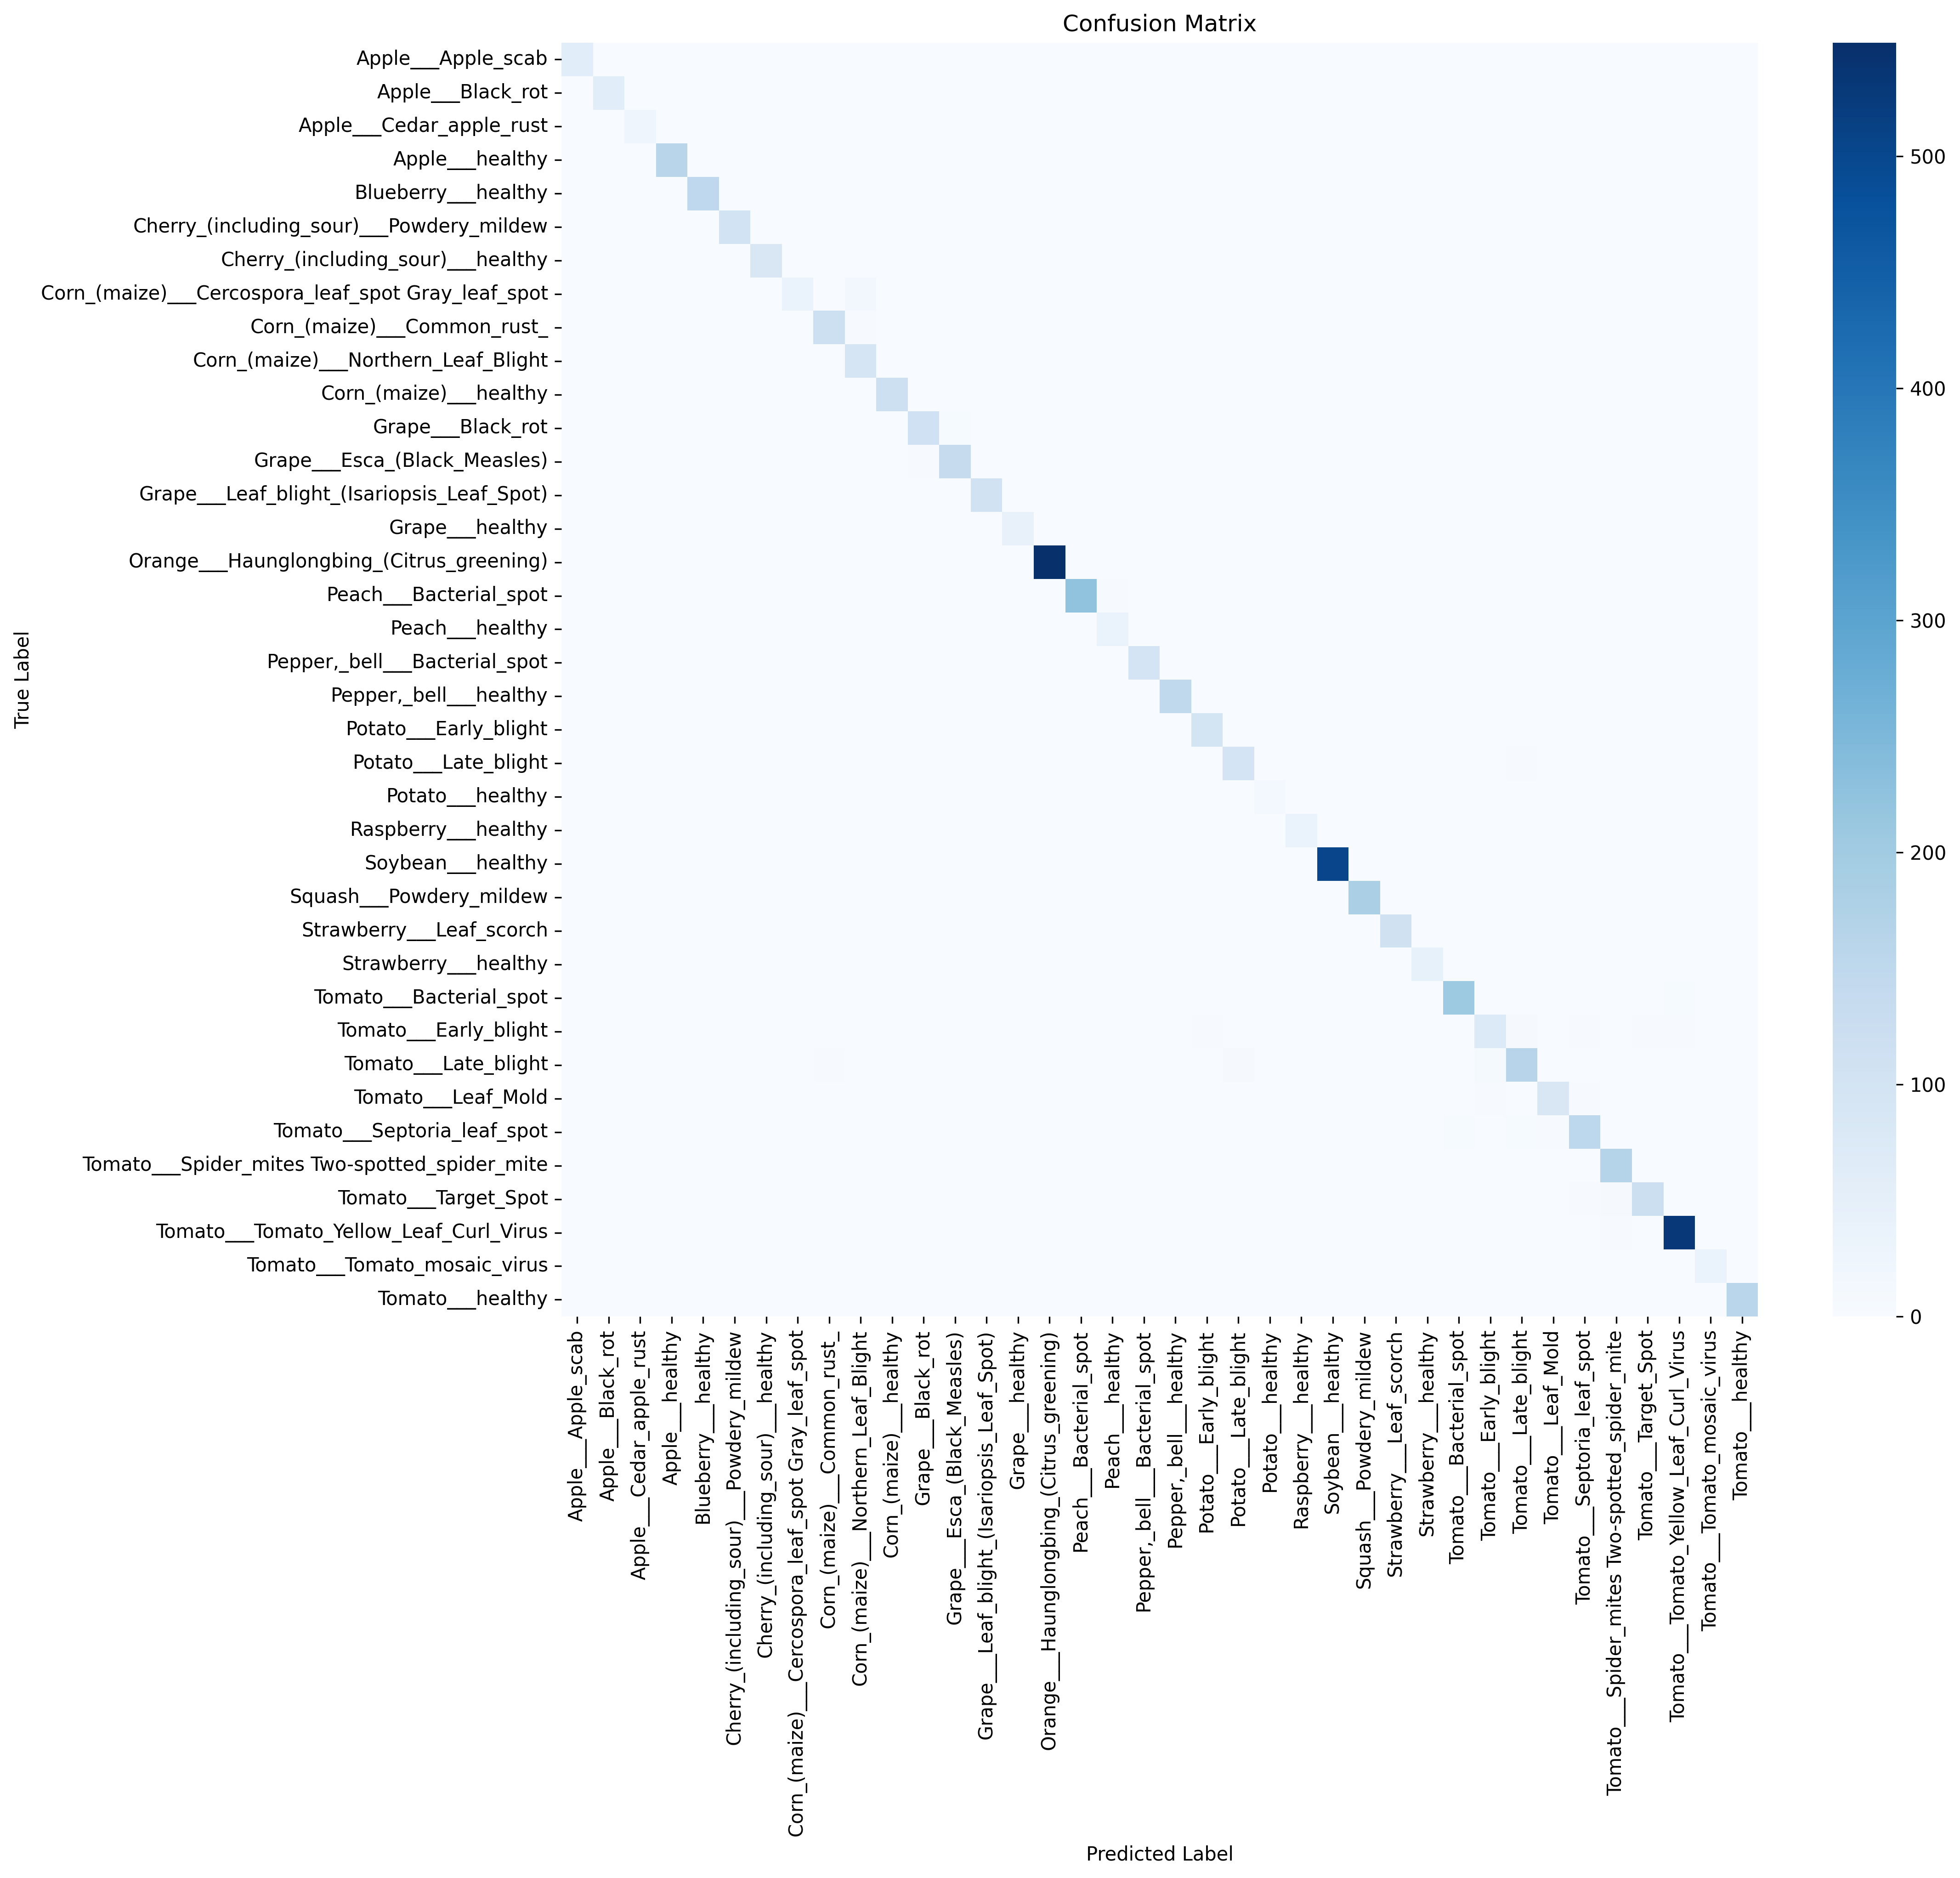

In [23]:
cm_path = FIGURE_DIR / 'confusion_matrix.png'

if cm_path.exists():
    display(Image(filename=str(cm_path)))
else:
    print('Chưa tìm thấy confusion_matrix.png.')

## 13. So sánh dropout 0.2 và 0.8

Dropout được dùng để giảm overfitting. Tuy nhiên dropout quá lớn như 0.8 có thể làm mô hình học kém vì quá nhiều neuron bị tắt trong quá trình huấn luyện.

In [24]:
if TRAIN_LOG_PATH.exists():
    df_log = pd.read_csv(TRAIN_LOG_PATH)

    # Lấy dropout từ tên phase, ví dụ:
    # dropout_0.2_freeze
    # dropout_0.2_finetune
    df_log["dropout"] = df_log["phase"].str.extract(r"dropout_([0-9.]+)").astype(float)

    # Lấy kết quả cuối cùng của giai đoạn fine-tune cho mỗi dropout
    df_dropout = (
        df_log[df_log["phase"].str.contains("finetune", case=False, na=False)]
        .sort_values(["dropout", "epoch"])
        .groupby("dropout")
        .tail(1)
        .reset_index(drop=True)
    )

    df_dropout_summary = df_dropout[[
        "dropout",
        "train_acc",
        "val_acc",
        "train_loss",
        "val_loss",
        "avg_time_per_epoch"
    ]].rename(columns={
        "dropout": "Dropout",
        "train_acc": "Final Training Accuracy",
        "val_acc": "Final Validation Accuracy",
        "train_loss": "Final Training Loss",
        "val_loss": "Final Validation Loss",
        "avg_time_per_epoch": "Average Time per Epoch"
    })

    display(df_dropout_summary)

else:
    print("Chưa tìm thấy training_log.csv.")

,Dropout,Final Training Accuracy,Final Validation Accuracy,Final Training Loss,Final Validation Loss,Average Time per Epoch
0,0.2,0.975463,0.984530,0.077427,0.047931,298.639949
1,0.8,0.912255,0.972007,0.268645,0.089537,296.268593


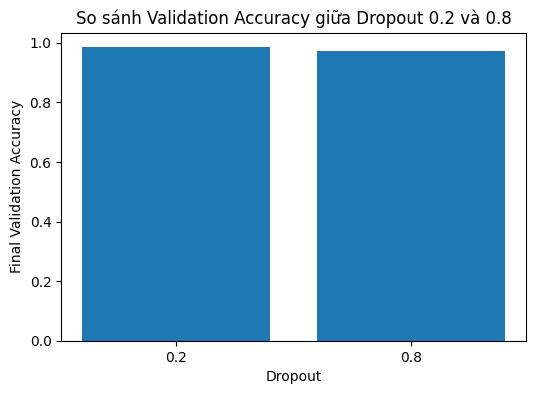

In [25]:
if TRAIN_LOG_PATH.exists():
    plt.figure(figsize=(6, 4))
    plt.bar(
        df_dropout_summary["Dropout"].astype(str),
        df_dropout_summary["Final Validation Accuracy"]
    )
    plt.xlabel("Dropout")
    plt.ylabel("Final Validation Accuracy")
    plt.title("So sánh Validation Accuracy giữa Dropout 0.2 và 0.8")
    plt.show()
else:
    print("Chưa có dữ liệu để vẽ biểu đồ dropout.")

## 14. Nhận xét dropout


 Kết quả cho thấy mô hình sử dụng dropout 0.2 đạt hiệu quả tốt hơn so với dropout 0.8. Nguyên nhân là dropout 0.2 giúp giảm overfitting ở mức vừa phải, trong khi dropout 0.8 loại bỏ quá nhiều thông tin trong quá trình huấn luyện, khiến mô hình khó học được đặc trưng phân biệt giữa các lớp bệnh lá cây.